In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [3]:
target_products = [
    'Credit card', 'Credit card or prepaid card',
    'Checking or savings account', 'Bank account or service',
    'Money transfer, virtual currency, or money service', 'Money transfers',
    'Consumer Loan', 'Payday loan, title loan, or personal loan',
    'Payday loan, title loan, personal loan, or advance loan'
]

product_mapping = {
    'Credit card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Checking or savings account': 'Savings Account',
    'Bank account or service': 'Savings Account',
    'Money transfer, virtual currency, or money service': 'Money Transfer',
    'Money transfers': 'Money Transfer',
    'Consumer Loan': 'Personal Loan',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Payday loan, title loan, personal loan, or advance loan': 'Personal Loan'
}

def clean_text_fast(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

output_path = r'C:\Users\pc\rag-complaint-chatbot\data\processed\filtered_complaints.csv'
total_saved = 0
writer_done = False

with open(output_path, 'w', newline='', encoding='utf-8') as f:
    for chunk in pd.read_csv(
        r'C:\Users\pc\rag-complaint-chatbot\data\raw\complaints.csv',
        chunksize=50000,
        low_memory=False
    ):
        chunk = chunk[chunk['Product'].isin(target_products)]
        chunk = chunk[chunk['Consumer complaint narrative'].notna()]

        if len(chunk) == 0:
            continue

        chunk['product_category'] = chunk['Product'].map(product_mapping)
        chunk['cleaned_narrative'] = chunk['Consumer complaint narrative'].apply(clean_text_fast)
        chunk = chunk[chunk['cleaned_narrative'].str.len() >= 50]

        chunk_final = chunk[[
            'Complaint ID', 'Date received', 'Product',
            'product_category', 'Issue', 'Sub-issue',
            'Company', 'State', 'cleaned_narrative'
        ]].copy()

        chunk_final.columns = [
            'complaint_id', 'date_received', 'product',
            'product_category', 'issue', 'sub_issue',
            'company', 'state', 'cleaned_narrative'
        ]

        if not writer_done:
            chunk_final.to_csv(f, index=False)
            writer_done = True
        else:
            chunk_final.to_csv(f, index=False, header=False)

        total_saved += len(chunk_final)
        print(f"Saved {total_saved} rows...")

print(f"\nDone! Total: {total_saved} rows saved!")

Saved 106 rows...
Saved 420 rows...
Saved 721 rows...
Saved 915 rows...
Saved 1107 rows...
Saved 1449 rows...
Saved 1859 rows...
Saved 2138 rows...
Saved 2612 rows...
Saved 3196 rows...
Saved 4030 rows...
Saved 4795 rows...
Saved 5613 rows...
Saved 6667 rows...
Saved 8030 rows...
Saved 10121 rows...
Saved 12412 rows...
Saved 16122 rows...
Saved 18900 rows...
Saved 19951 rows...
Saved 21219 rows...
Saved 22561 rows...
Saved 24110 rows...
Saved 25735 rows...
Saved 27275 rows...
Saved 28581 rows...
Saved 29490 rows...
Saved 30437 rows...
Saved 31744 rows...
Saved 32986 rows...
Saved 33963 rows...
Saved 34943 rows...
Saved 36071 rows...
Saved 37472 rows...
Saved 39173 rows...
Saved 41198 rows...
Saved 43109 rows...
Saved 46171 rows...
Saved 51527 rows...
Saved 60455 rows...
Saved 67389 rows...
Saved 70288 rows...
Saved 72446 rows...
Saved 74257 rows...
Saved 75813 rows...
Saved 77728 rows...
Saved 79412 rows...
Saved 81222 rows...
Saved 82934 rows...
Saved 84383 rows...
Saved 85891 rows...

In [8]:
# Load a small sample to verify
df = pd.read_csv(output_path, nrows=5000)

print(f"Shape (sample): {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nCategory distribution:")
print(df['product_category'].value_counts())
print(f"\nSample narrative:")
print(df['cleaned_narrative'].iloc[0][:200])

Shape (sample): (5000, 9)

Columns: ['complaint_id', 'date_received', 'product', 'product_category', 'issue', 'sub_issue', 'company', 'state', 'cleaned_narrative']

Category distribution:
product_category
Credit Card        1908
Savings Account    1904
Money Transfer      911
Personal Loan       277
Name: count, dtype: int64

Sample narrative:
a xxxx xxxx card was opened under my name by a fraudster. i received a notice from xxxx that an account was just opened under my name. i reached out to xxxx xxxx to state that this activity was unauth


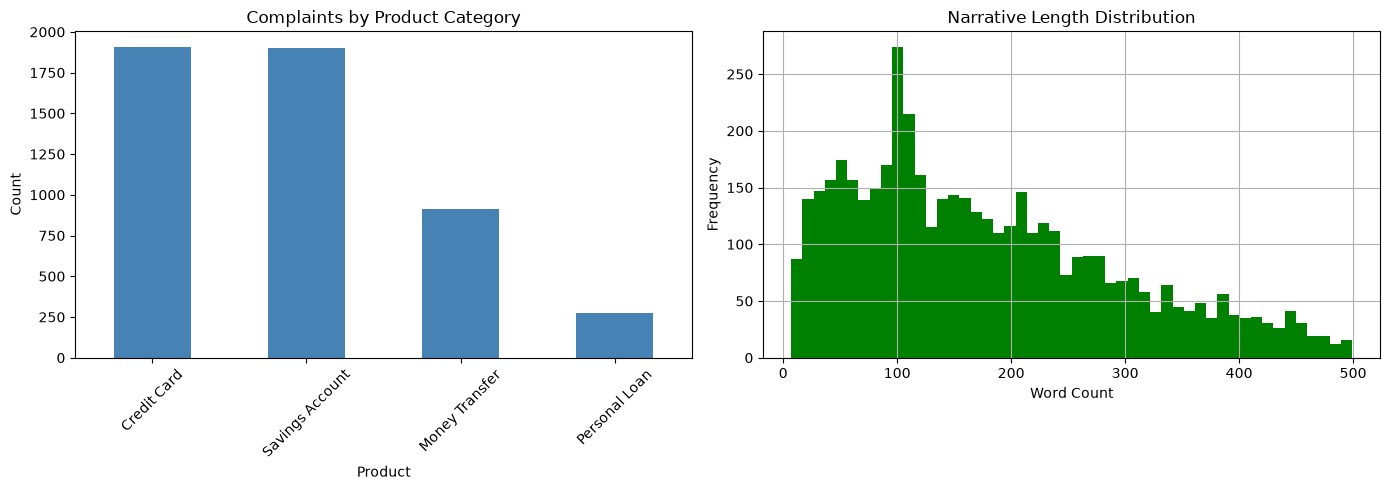

Done!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Category distribution
df['product_category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Complaints by Product Category')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 - Narrative length using cleaned_narrative
df['narrative_length'] = df['cleaned_narrative'].apply(lambda x: len(str(x).split()))
df[df['narrative_length'] < 500]['narrative_length'].hist(bins=50, ax=axes[1], color='green')
axes[1].set_title('Narrative Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(r'C:\Users\pc\rag-complaint-chatbot\notebooks\eda_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Done!")